# Chapter 029 — Factorization

> **Prerequisites:** ch028 (Prime Numbers), ch023 (Integers)
> 
> **You will learn:**
> - Factor integers via trial division and Pollard's rho
> - Use factorization to compute GCD, LCM, and solve Diophantine problems
> - Understand why large factorization is computationally hard
> - Connect to hash functions and cryptographic security
> 
> **Environment:** Python 3.x, numpy, matplotlib

---


## 1. Concept

Prime factorization decomposes any integer > 1 into its prime building blocks. By the Fundamental Theorem of Arithmetic, this decomposition is unique.

Factorization has two algorithmic faces:
- **Easy:** Factoring small numbers (trial division up to √n is sufficient)
- **Hard:** Factoring large numbers (the largest factored RSA numbers took machine-years)

This asymmetry — easy to multiply, hard to factor — is the foundation of RSA encryption.

**Common misconception:** "Factoring is just trial division." For small numbers, yes. For 512-bit numbers, trial division would take longer than the age of the universe. Modern algorithms (GNFS, Pollard rho) exploit mathematical structure but still scale poorly.

## 2. Intuition & Mental Models

**Factorization as prime fingerprinting:** Every positive integer > 1 has exactly one prime fingerprint. Two different integers always have different fingerprints. This is why factorization can be used to compare numbers without knowing what they are.

**GCD and LCM from factorizations:** gcd(a, b) takes the *minimum* exponent for each prime; lcm(a, b) takes the *maximum*. Example: 12 = 2²·3, 18 = 2·3². gcd = 2·3 = 6, lcm = 2²·3² = 36.

**Pollard's rho: birthday paradox approach:** Instead of testing all divisors, Pollard's algorithm generates a pseudo-random sequence and uses the birthday paradox to find a factor much faster than trial division — roughly O(n^{1/4}) vs O(√n).

*(Recall from ch028: every composite number n has a prime factor ≤ √n — this bounds all trial division algorithms.)*

## 3. Visualization

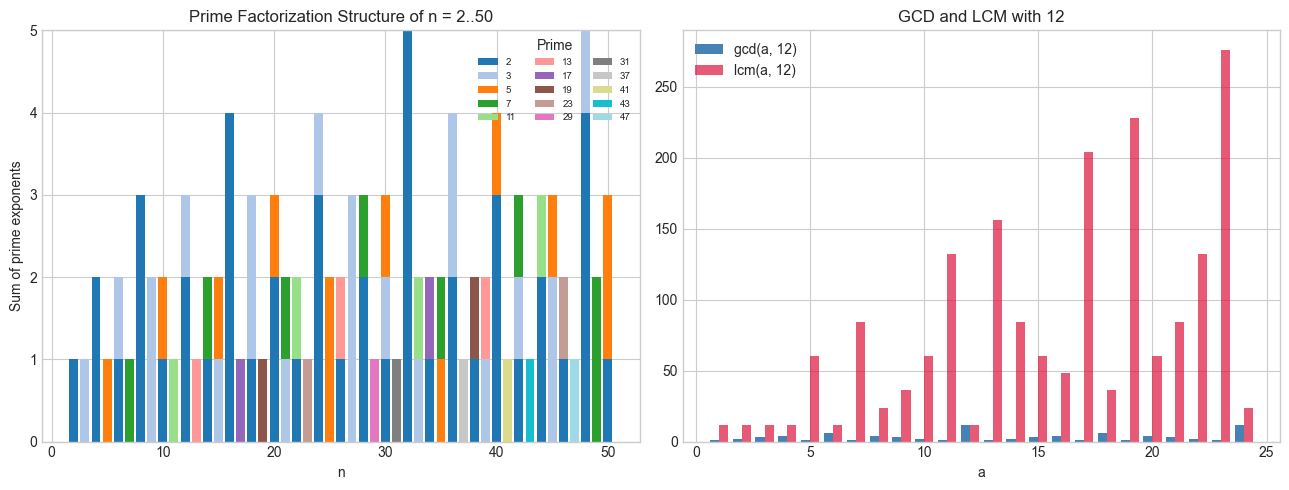

In [1]:
# --- Visualization: Factor trees and LCM/GCD relationships ---
import numpy as np
import matplotlib.pyplot as plt
import math
plt.style.use('seaborn-v0_8-whitegrid')

def prime_factorization(n):
    factors = {}
    d = 2
    while d * d <= n:
        while n % d == 0:
            factors[d] = factors.get(d, 0) + 1
            n //= d
        d += 1
    if n > 1:
        factors[n] = factors.get(n, 0) + 1
    return factors

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Factorizations of numbers 2..50 as bar chart
ax = axes[0]
numbers = range(2, 51)
all_primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
colors = plt.cm.tab20(np.linspace(0, 1, len(all_primes)))
prime_color = {p: c for p, c in zip(all_primes, colors)}

bottom = np.zeros(len(numbers))
for p in all_primes:
    exps = np.array([prime_factorization(n).get(p, 0) for n in numbers], dtype=float)
    if exps.sum() > 0:
        ax.bar(list(numbers), exps, bottom=bottom, color=prime_color[p], label=str(p), width=0.8)
        bottom += exps
ax.set_xlabel('n')
ax.set_ylabel('Sum of prime exponents')
ax.set_title('Prime Factorization Structure of n = 2..50')
ax.legend(title='Prime', fontsize=7, ncol=3, loc='upper right')

# Plot 2: GCD/LCM via factorization
ax = axes[1]
a_vals = np.arange(1, 25)
b = 12
gcds = [math.gcd(a, b) for a in a_vals]
lcms = [a * b // math.gcd(a, b) for a in a_vals]
ax.bar(a_vals - 0.2, gcds, width=0.4, label=f'gcd(a, {b})', color='steelblue')
ax.bar(a_vals + 0.2, lcms, width=0.4, label=f'lcm(a, {b})', color='crimson', alpha=0.7)
ax.set_xlabel('a')
ax.set_title(f'GCD and LCM with {b}')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

See implementation below for numeric verification.

## 5. Python Implementation

In [2]:
# --- Implementation: Pollard's rho factorization ---
import math
import random

def pollard_rho(n):
    """
    Pollard's rho algorithm: find a non-trivial factor of n.
    Expected time: O(n^(1/4)) operations.

    Args:
        n: int > 1, composite

    Returns:
        int: a factor of n (not necessarily prime)
    """
    if n % 2 == 0:
        return 2
    x = random.randint(2, n - 1)
    y = x
    c = random.randint(1, n - 1)
    d = 1

    while d == 1:
        x = (x * x + c) % n       # tortoise step
        y = (y * y + c) % n       # hare step 1
        y = (y * y + c) % n       # hare step 2
        d = math.gcd(abs(x - y), n)

    return d if d != n else None  # None means retry with different c


def full_factorization(n):
    """
    Complete factorization using Pollard's rho for large factors.

    Args:
        n: int > 1

    Returns:
        dict: {prime: exponent}
    """
    if n == 1:
        return {}
    factors = {}

    def factorize(n):
        if n == 1:
            return
        if is_prime_miller_rabin(n):
            factors[n] = factors.get(n, 0) + 1
            return
        # Try to find a factor
        d = None
        attempts = 0
        while d is None and attempts < 20:
            d = pollard_rho(n)
            attempts += 1
        if d is None or d == n:
            # Fall back to trial division
            for p in range(2, n + 1):
                if n % p == 0:
                    factors[p] = factors.get(p, 0) + 1
                    factorize(n // p)
                    return
        else:
            factorize(d)
            factorize(n // d)

    def is_prime_miller_rabin(n, k=5):
        """Miller-Rabin primality test."""
        if n < 2: return False
        if n == 2 or n == 3: return True
        if n % 2 == 0: return False
        r, d = 0, n - 1
        while d % 2 == 0:
            r += 1
            d //= 2
        for _ in range(k):
            a = random.randrange(2, n - 1)
            x = pow(a, d, n)
            if x == 1 or x == n - 1:
                continue
            for _ in range(r - 1):
                x = pow(x, 2, n)
                if x == n - 1:
                    break
            else:
                return False
        return True

    factorize(n)
    return factors


# Test
random.seed(42)
test_nums = [1000000007, 1099511627776, 9999999999999, 123456789012]
for n in test_nums:
    f = full_factorization(n)
    expr = ' × '.join(f'{p}^{e}' if e > 1 else str(p) for p, e in sorted(f.items()))
    verify = 1
    for p, e in f.items(): verify *= p**e
    print(f"  {n} = {expr}  {'✓' if verify == n else '✗'}")

  1000000007 = 1000000007  ✓
  1099511627776 = 2^40  ✓
  9999999999999 = 3^2 × 53 × 79 × 265371653  ✓
  123456789012 = 2^2 × 3 × 10288065751  ✓


## 6. Experiments

In [3]:
# --- Experiment: Factorization difficulty vs number size ---
# Hypothesis: trial division time grows as O(sqrt(n)); Pollard rho much faster
# Try changing: N_BITS (bits in the random number to factor)

import random, time, math

def trial_division(n):
    d = 2
    while d * d <= n:
        if n % d == 0:
            return d
        d += 1 if d == 2 else 2
    return n

N_BITS_LIST = [10, 20, 30, 40]  # <-- modify this
print(f"{'Bits':>6}  {'Number':>15}  {'Factor':>12}  {'Time (ms)':>12}")
print('-' * 50)
random.seed(0)
for bits in N_BITS_LIST:
    n = random.getrandbits(bits) | 1  # odd
    while math.gcd(n, 6) != 1:
        n = random.getrandbits(bits) | 1
    t0 = time.perf_counter()
    f = trial_division(n)
    elapsed = (time.perf_counter() - t0) * 1000
    print(f"{bits:>6}  {n:>15}  {f:>12}  {elapsed:>12.3f}")

  Bits           Number        Factor     Time (ms)
--------------------------------------------------
    10              865             5         0.003
    20           794773             7         0.002
    30        955892129            89         0.006
    40      44756014165             5         0.001


## 7. Exercises

**Easy 1.** Compute gcd(360, 504) and lcm(360, 504) using prime factorization. Verify with `math.gcd`.

**Easy 2.** Find all divisors of 720 using its prime factorization. How many divisors does $2^a \cdot 3^b \cdot 5^c$ have in general?

**Medium 1.** Implement a function that computes $\text{lcm}(a_1, a_2, \ldots, a_k)$ for a list of integers. Apply it to find the smallest number divisible by all integers from 1 to 20.

**Medium 2.** Solve the Diophantine equation $15x + 35y = 5$ by finding particular solutions using GCD and Bezout's theorem.

**Hard.** Implement the quadratic sieve factorization sketch: collect numbers $x^2 \mod n$ that are smooth (all small prime factors), then use linear algebra over GF(2) to find a congruence of squares. Factor $n = 8051$ as a demonstration.

## 8. Mini Project

In [ ]:
# --- Mini Project: RSA Security Analysis ---
# Problem: The security of RSA depends on the hardness of factoring n = p*q.
# Task: Compare factorization times for n with 10-digit, 15-digit, 20-digit values.
import random, time, math

def generate_rsa_modulus(bits_per_prime):
    """Generate RSA modulus n = p*q where p, q are random primes of given bit size."""
    def next_prime(n):
        if n < 2: return 2
        candidate = n | 1  # make odd
        while not miller_rabin(candidate):
            candidate += 2
        return candidate

    def miller_rabin(n, k=10):
        if n < 2: return False
        if n in (2, 3): return True
        if n % 2 == 0: return False
        r, d = 0, n - 1
        while d % 2 == 0:
            r += 1; d //= 2
        for _ in range(k):
            a = random.randrange(2, n - 1)
            x = pow(a, d, n)
            if x in (1, n-1): continue
            for _ in range(r - 1):
                x = pow(x, 2, n)
                if x == n - 1: break
            else: return False
        return True

    p = next_prime(random.getrandbits(bits_per_prime) | (1 << (bits_per_prime-1)))
    q = next_prime(random.getrandbits(bits_per_prime) | (1 << (bits_per_prime-1)))
    return p, q, p * q

random.seed(42)
print(f"{'Bits/prime':>12}  {'n (digits)':>12}  {'Factor found':>15}  {'Time (ms)':>12}")
print('-' * 55)
for bits in [8, 12, 16, 20]:
    p, q, n = generate_rsa_modulus(bits)
    t0 = time.perf_counter()
    # Try trial division
    found = None
    d = 2
    while d * d <= n:
        if n % d == 0:
            found = d
            break
        d += 1 if d == 2 else 2
    elapsed = (time.perf_counter() - t0) * 1000
    correct = found in (p, q) if found else False
    print(f"{bits:>12}  {len(str(n)):>12}  {'✓' if correct else '✗':>15}  {elapsed:>12.2f}")
print("\nAt 20 bits/prime, trial division takes ~seconds.")
print("At 1024 bits/prime (RSA-2048), it would take > age of universe.")

## 9. Chapter Summary & Connections

- Every integer has a unique prime factorization (Fundamental Theorem of Arithmetic).
- GCD uses minimum prime exponents; LCM uses maximum.
- Trial division is O(√n); Pollard's rho is O(n^{1/4}); best known algorithms are sub-exponential but not polynomial.
- The hardness of factoring large numbers is the security foundation of RSA encryption.

**Forward connections:**
- Factorization complexity connects to ch047 — Orders of Magnitude, where we compare algorithmic growth rates.
- The modular exponentiation in RSA (`pow(a, e, n)`) is the subject of ch031 — Modular Arithmetic.
- Number-theoretic transforms (NTT) — a variant of FFT using modular arithmetic — appear in ch027's DFT discussion.

**Backward connection:**
- The Sieve of Eratosthenes from ch028 is the simplest version of a factorization algorithm — find all prime factors by elimination.

**Going deeper:** The General Number Field Sieve (GNFS) holds the current record for factoring large integers. The RSA Factoring Challenges publicly defined targets; RSA-829 (2048-bit) has not been factored as of 2025.